## Praktikum 12 - Machine Learning
## ***Principal Component Analysis (PCA)***
## Dataset Wine
### Muhammad Rizqi Nurrohmat - 0110224001

### 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from mpl_toolkits.mplot3d import Axes3D

plt.rcParams['figure.figsize'] = (8, 6)

### 2. Load Dataset

In [2]:
wine = load_wine()

df = pd.DataFrame(data=wine.data, columns=wine.feature_names)
df['target'] = wine.target

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


### 3. Eksplorasi Awal Dataset

In [ ]:
# melihat info dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  targe

In [ ]:
# statistik deskriptif
df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


In [ ]:
# cek missing value
df.isnull().sum()

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
dtype: int64

In [6]:
# cek duplikat data
df.duplicated().sum()

np.int64(0)

In [7]:
# distribusi kelas target
print("Nama Kelas:", wine.target_names)
df['target'].value_counts()

Nama Kelas: ['class_0' 'class_1' 'class_2']


target
1    71
0    59
2    48
Name: count, dtype: int64

### 4. Fitur dan Label

In [8]:
# fitur dan label
X = wine.data
y = wine.target

print("Shape X:", X.shape)
print("Shape y", y.shape)

Shape X: (178, 13)
Shape y (178,)


### 5. Pembagian Data Latih dan Data Uji

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Shape X_train:", X_train.shape)
print("Shape X_test:", X_test.shape)

Shape X_train: (142, 13)
Shape X_test: (36, 13)


### 6. Standarisasi Data (Mean= 0, std=1)

In [10]:
# standarisasi
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_test_scaled[:5]

array([[ 1.41119819, -0.16402402, -0.24252429, -0.48245458,  0.36051624,
         1.09205418,  1.40697489, -1.17972837,  1.34974202,  0.32679269,
         1.33282168,  0.82041452,  2.5646805 ],
       [-0.57707218, -1.002369  , -0.42948655, -0.63086999, -0.98314008,
        -0.44203005, -1.4815107 ,  2.01917328, -0.60618325,  0.19785532,
        -0.88106423, -1.5951252 , -0.29783054],
       [ 1.12358675, -0.4009476 ,  1.62709836, -0.06689145,  0.49488187,
         1.09205418,  1.03800775,  0.08299597,  0.27657949, -0.21044638,
         1.33282168,  1.15509773,  0.58422228],
       [-1.76503247, -0.26426092,  3.23497383,  2.63426892,  1.30107566,
         1.46346405,  3.26235249,  0.92481219,  0.46697929,  0.43424051,
        -0.0840653 ,  1.57708961, -0.91360326],
       [ 0.87348985, -0.99325656, -1.6634375 , -0.48245458, -0.37849474,
        -0.2805475 , -0.2059386 , -0.33791215, -1.50625505, -0.51130026,
         1.24426624, -0.21273801, -0.36440056]])

### 7. Penerapan Model SVM tanpa PCA (Baseline Model)

In [12]:
# mdoel svm tanpa PCA
svm_no_pca = SVC(kernel='rbf', gamma='scale', random_state=42)
svm_no_pca.fit(X_train_scaled, y_train)

# prediksi dan evaluasi
y_pred_no_pca = svm_no_pca.predict(X_test_scaled)

acc_no_pca = accuracy_score(y_test, y_pred_no_pca)
print("Akurasi tanpa PCA:", acc_no_pca)

print("Classification Report tanpa PCA:\n", classification_report(y_test, y_pred_no_pca))
print(classification_report(y_test, y_pred_no_pca, target_names=wine.target_names))


Akurasi tanpa PCA: 0.9722222222222222
Classification Report tanpa PCA:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.93      1.00      0.97        14
           2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36

              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       0.93      1.00      0.97        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



### 8. Penerapan PCA

In [13]:
# PCA dengan 3 komponen utama
pca = PCA(n_components=3)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Shape X_train_pca:", X_train_pca.shape)
print("Shape X_test_pca:", X_test_pca.shape)

Shape X_train_pca: (142, 3)
Shape X_test_pca: (36, 3)


### 9. Menampilkan Varian Komponen PCA

In [14]:
# variasi yang dijelaskan oleh masing-masing komponen
explained_variance = pca.explained_variance_ratio_
print("Explained Variance Ratio:", explained_variance)
print("Total Explained Variance (3 components):", np.sum(explained_variance))

Explained Variance Ratio: [0.35792104 0.19270671 0.11019835]
Total Explained Variance (3 components): 0.6608261082211258


Visualisasi Explained Variance Ratio dalam bentuk diagram batang (bar chart).

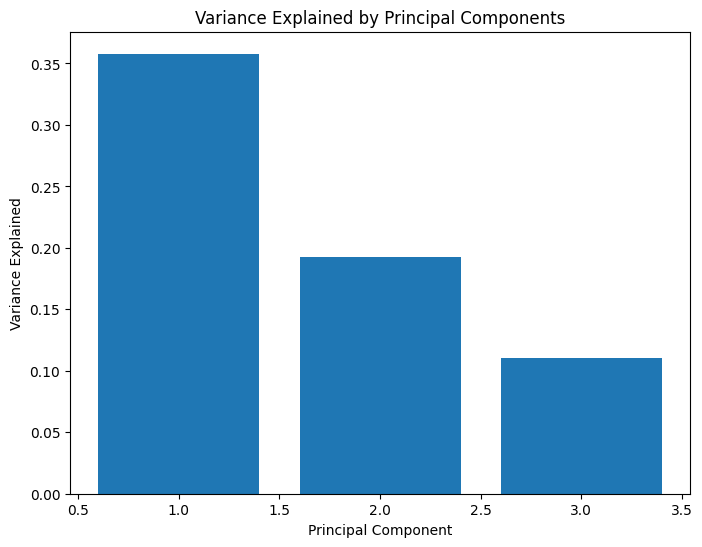

In [15]:
plt.bar([1,2,3], explained_variance)
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.title('Variance Explained by Principal Components')
plt.show()

### 10. Membangun Model SVM dengan PCA

In [16]:
# model svm dengan PCA
svm_pca = SVC(kernel='rbf', gamma='scale', random_state=42)
svm_pca.fit(X_train_pca, y_train)

# prediksi dan evaluasi
y_pred_pca = svm_pca.predict(X_test_pca)

acc_pca = accuracy_score(y_test, y_pred_pca)
print("Akurasi dengan PCA:", acc_pca)

print("Classification Report dengan PCA:\n", classification_report(y_test, y_pred_pca))
print(classification_report(y_test, y_pred_pca, target_names=wine.target_names))

Akurasi dengan PCA: 0.9722222222222222
Classification Report dengan PCA:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.93      1.00      0.97        14
           2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36

              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       0.93      1.00      0.97        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



### 11. Visualisasi PCA dalam Ruang 3 Dimensi

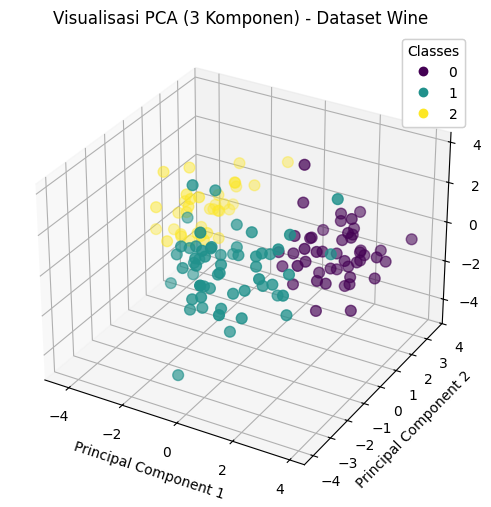

In [17]:
# visualisasi 3D PCA (menggunakan data train)
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X_train_pca[:, 0], 
    X_train_pca[:, 1], 
    X_train_pca[:, 2], 
    c=y_train,  
    s=60
)

ax.set_title('Visualisasi PCA (3 Komponen) - Dataset Wine')
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')

# tambahkan legend berdasarkan kelas
legend1 = ax.legend(
    *scatter.legend_elements(), 
    title="Classes",
)
ax.add_artist(legend1)
plt.show()

### 12. Perbandingan Model SVM dengan dan tanpa PCA

In [18]:
# membandingkan hasil model tnapa dan dengan PCA
comparison_df = pd.DataFrame({
    'Model' : ['SVM tanpa PCA', 'SVM dengan PCA'],
    'Jumlah Fitur': [X_train.shape[1], X_train_pca.shape[1]],
    'Akurasi': [acc_no_pca, acc_pca],
    'variasi total PCA' : [None, explained_variance.sum()]
})

comparison_df

,Model,Jumlah Fitur,Akurasi,variasi total PCA
0,SVM tanpa PCA,13,0.972222,NaN
1,SVM dengan PCA,3,0.972222,0.660826
